# Notebook 8 — Unsupervised typologies of residential trajectories

Two complementary clusterings of the NB7 modelling population: a
trajectory-based typology (Blocks 1-3) and an entry-profile typology
(Blocks 4a-4c), followed by the spatial contingency of the entry
profiles (Block 5).

## Block 0 — Clustering population and derived variables

This block builds the single working table for the whole notebook: both the
trajectory clustering (Blocks 1-3) and the profile-based clustering
(Blocks 4a-4c) reuse the `pop` dataframe created here. The population is the
modelling perimeter of NB7 (298,421 individuals: deaths and pending
departures excluded).

Derived variables: mobility intensity (episodes per observed year, the
observation duration floored at 3 months to avoid division artifacts), and
the transforms required by k-means' sensitivity to outliers — log of the
median episode duration, log of household size, and intensity winsorised at
the 99th percentile. The trajectory feature matrix is standardised here;
the profile matrix is built in Block 4a from the same `pop`.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler

DATA_DIR = Path("/mnt/o/09_STATISTIQUES/09_04_Explorations/MR/CAS ADS/Final project/data")
RANDOM_STATE = 42

# --- Single working table for the whole notebook (Blocks 1-3 and 4a-4c) ---
pers = pd.read_parquet(DATA_DIR / "persons_analytical_enriched.parquet")
pop = pers[~pers["depart_status"].isin(["death", "pending_anticipated"])].copy()
print(f"Clustering population: {len(pop):,}")
split_nb7 = pd.read_parquet(DATA_DIR / "nb7_model_population.parquet")
assert set(pop["id_projet"]) == set(split_nb7["id_projet"]), \
    "Perimeter differs from NB7 -- re-run NB7 Block 0 (or delete its split file)"

# --- Derived trajectory variables (used by both typologies) ---
pop["duree_obs_annees"]   = (pop["duree_totale_j"] / 365.25).clip(lower=0.25)
pop["intensite_mobilite"] = pop["n_episodes"] / pop["duree_obs_annees"]

# --- Transforms for k-means (outlier-sensitive) ---
pop["log_duree_median"] = np.log1p(pop["duree_median_ep_j"])
pop["log_menage"]       = np.log1p(pop["menage_taille"])
p99 = pop["intensite_mobilite"].quantile(0.99)
pop["intensite_w"] = pop["intensite_mobilite"].clip(upper=p99)
print(f"intensite_mobilite winsorised at p99 = {p99:.2f}")

# --- Trajectory feature matrix (Blocks 1-3) ---
CLUSTER_FEATS = ["n_episodes", "log_duree_median", "intensite_w",
                 "age_entree", "log_menage"]
X = pop[CLUSTER_FEATS].fillna(pop[CLUSTER_FEATS].median())
print(X.describe().round(2).to_string())
X_std = StandardScaler().fit_transform(X)
print(f"\nStandardised matrix: {X_std.shape}")

## Block 1 — Choosing the number of clusters

K-means is fitted for k = 2 to 8 on the standardised features. The inertia
curve (elbow) is computed on the full population; the silhouette score, whose
cost is quadratic, is estimated on a random sample of 20,000 individuals.
Both criteria are reported with the retained k justified; cluster stability
is checked in the next block by re-running with different seeds.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

rng = np.random.RandomState(RANDOM_STATE)
idx_s = rng.choice(len(X_std), 20_000, replace=False)

ks, inerties, silhouettes = range(2, 9), [], []
# n_init=30: with fewer restarts the selection fits can land on poor local
# optima and distort the silhouette comparison across k.
for k in ks:
    km = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_std)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_std[idx_s], labels[idx_s]))
    print(f"k={k}: inertia={km.inertia_:,.0f}, silhouette(20k)={silhouettes[-1]:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(ks, inerties, "o-"); ax1.set_xlabel("k"); ax1.set_ylabel("Inertia")
ax1.set_title("Elbow criterion")
ax2.plot(ks, silhouettes, "o-", color="tab:green")
ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette (n=20,000)")
ax2.set_title("Silhouette score")
fig.tight_layout()
fig.savefig(DATA_DIR.parent / "figures" / "nb8_k_selection.png", dpi=200)
plt.show()

## Block 2 — Final clustering (k=5), stability check and cluster profiles

The number of clusters is selected on three criteria, in this order: every
cluster must be a substantive trajectory type, the partition must be
reproducible across seeds, and the choice should be consistent with the
inertia elbow. Silhouette scores (random sample of 20,000 individuals, as the
silhouette cost is quadratic) plateau around k = 5–6 with a marginal peak at
k = 6; the sixth cluster, however, is an artifact group of large collective
households (0.9% of the population, median household size ~70) rather than a
trajectory type, and runs at `n_init=10` had shown the k = 6 partition to be
initialisation-sensitive. The cell below re-measures the stability of both
candidates at `n_init=30` (five refits each): k = 5 reaches mean ARI 0.998
(min 0.997) and k = 6 mean 0.996 (min 0.991) — both partitions are
reproducible, so stability does not discriminate between them, and the
earlier apparent instability of k = 6 was an initialisation artifact.
k = 5 is therefore retained on the first and third criteria: it is the
elbow-consistent partition in which every cluster is a substantive
trajectory type. The moderate absolute silhouette level (~0.3)
indicates overlapping clusters, expected for continuous human trajectories:
the partition is a descriptive typology, not naturally separated groups.

The final k-means is refitted at k = 5, its stability re-verified over five
seeds, and clusters are profiled on the clustering features (medians, original
scale) then characterised a posteriori on variables kept out of the
clustering: departure rate, censoring, entry type, permit group, nationality
and household type.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# --- Stability of the two silhouette front-runners (n_init=30, 5 refits) ---
for kk in [5, 6]:
    ref_k = KMeans(n_clusters=kk, n_init=30, random_state=RANDOM_STATE).fit_predict(X_std)
    aris_k = [adjusted_rand_score(ref_k,
              KMeans(n_clusters=kk, n_init=30, random_state=s).fit_predict(X_std))
              for s in [1, 7, 13, 42_000, 99]]
    print(f"trajectory k={kk}: ARI mean={np.mean(aris_k):.3f}, min={np.min(aris_k):.3f}")

# --- Final fit ---
K = 5
km = KMeans(n_clusters=K, n_init=30, random_state=RANDOM_STATE)
pop["cluster"] = km.fit_predict(X_std)

# --- Stability across seeds (adjusted Rand index vs reference) ---
aris = []
for seed in [1, 7, 13, 42_000, 99]:
    lab = KMeans(n_clusters=K, n_init=30, random_state=seed).fit_predict(X_std)
    aris.append(adjusted_rand_score(pop["cluster"], lab))
print(f"Stability (ARI over 5 seeds): mean={np.mean(aris):.3f}, min={np.min(aris):.3f}")

# --- Profiles on clustering features (original scale, medians) ---
prof = pop.groupby("cluster").agg(
    n=("id_projet", "size"),
    n_episodes=("n_episodes", "median"),
    duree_med_j=("duree_median_ep_j", "median"),
    intensite=("intensite_mobilite", "median"),
    age_entree=("age_entree", "median"),
    menage=("menage_taille", "median"),
).round(2)
prof["part"] = (prof["n"] / len(pop)).round(3)
print("\n=== Cluster profiles (medians, original scale) ===")
print(prof.to_string())

# --- A-posteriori characterisation (variables NOT used for clustering) ---
carac = pop.groupby("cluster").agg(
    taux_depart=("target_depart", "mean"),
    censure=("censure", "mean"),
    part_arrivee=("debut_type_premier", lambda s: (s == "arrivee").mean()),
    part_snapshot=("debut_type_premier", lambda s: (s == "snapshot").mean()),
    part_permis_P=("permis_groupe", lambda s: (s == "P").mean()),
    part_CH=("nat_groupe", lambda s: (s == "CH").mean()),
    part_collectif=("menage_type", lambda s: (s == "Collectif").mean()),
).round(3)
print("\n=== A-posteriori characterisation ===")
print(carac.to_string())

# --- Assign descriptive names, verified against the profiles above ---
# IMPORTANT: cluster numbering can permute between runs. Each name is
# anchored to an idxmin/idxmax signature; the assertion only guarantees the
# five anchors are distinct -- verify the printed profiles match the names.
med = pop.groupby("cluster")[["age_entree", "duree_median_ep_j",
                              "n_episodes", "intensite_mobilite"]].median()
c_children  = med["age_entree"].idxmin()                  # median age ~8
c_transient = med["intensite_mobilite"].idxmax()          # ~121-day stays
c_settled   = med["duree_median_ep_j"].idxmax()           # ~22-year stays
c_movers    = med["n_episodes"].idxmax()                  # 3+ episodes
c_arrivals  = list(set(range(K)) - {c_children, c_transient,
                                    c_settled, c_movers})[0]
assert len({c_children, c_transient, c_settled, c_movers, c_arrivals}) == 5

CLUSTER_NAMES = {
    c_children:  "Stock families/children",
    c_transient: "Short-stay transients",
    c_settled:   "Long-settled residents",
    c_movers:    "Internal movers",
    c_arrivals:  "Standard arrivals",
}
pop["cluster_name"] = pop["cluster"].map(CLUSTER_NAMES)
print("\nCluster naming:", CLUSTER_NAMES)

pop[["id_projet", "cluster", "cluster_name"]].to_parquet(
    DATA_DIR / "nb8_clusters.parquet", index=False)

## Block 3 — Figure: cluster visualisation and departure rate by cluster

The five clusters are visualised in two panels. The left panel projects the
standardised clustering features on the first two principal components, on a
random sample of 30,000 individuals (plotting all 298,421 points would only
saturate the figure). The explained variance of each component is reported on
the axes. The projection is a visual aid only: clusters were fitted in the
full five-dimensional feature space, and some overlap in two dimensions is
expected given the moderate silhouette score.

The right panel shows the departure rate of each cluster, with the overall
rate as a reference line. This is the key validation of the typology: the
departure outcome was never used in the clustering, yet the clusters order
themselves from about 30% (long-settled residents) to about 80% (short-stay
transients). The unsupervised typology therefore recovers, independently,
the main determinants identified by the supervised model: residence permit
status, age at entry and residential intensity. Cluster labels are short
descriptive names assigned from the profile tables of Block 2.

PCA explained variance: [0.402 0.238]


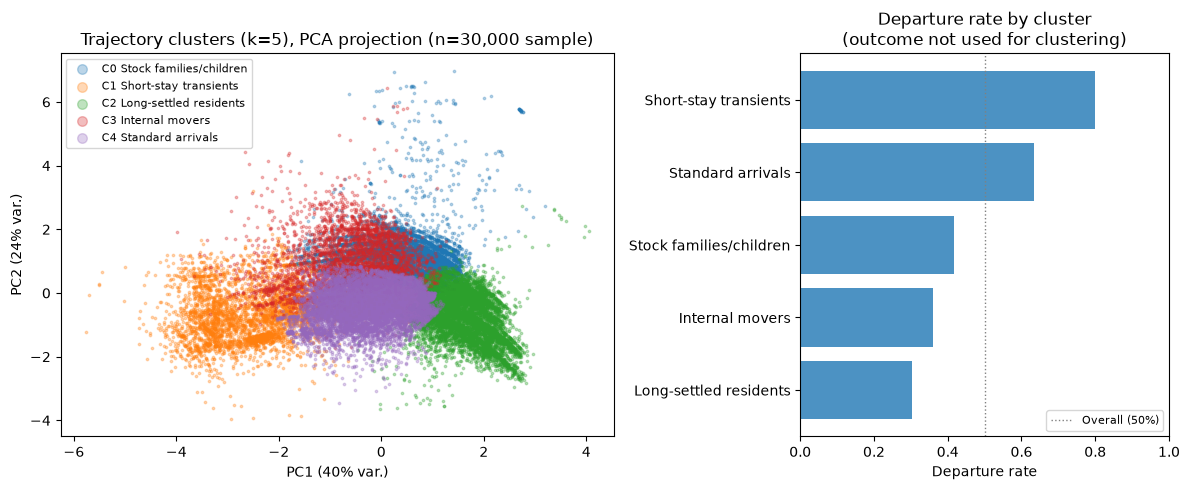

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=RANDOM_STATE)
XY = pca.fit_transform(X_std)
print(f"PCA explained variance: {pca.explained_variance_ratio_.round(3)}")

rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(XY), 30_000, replace=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5),
                               gridspec_kw={"width_ratios": [3, 2]})
for c in range(K):
    m = pop["cluster"].values[idx] == c
    ax1.scatter(XY[idx][m, 0], XY[idx][m, 1], s=3, alpha=0.3,
                label=f"C{c} {CLUSTER_NAMES[c]}")
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var.)")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var.)")
ax1.set_title(f"Trajectory clusters (k={K}), PCA projection (n=30,000 sample)")
ax1.legend(fontsize=8, markerscale=4)

taux = pop.groupby("cluster_name")["target_depart"].mean().sort_values()
ax2.barh(taux.index, taux.values, color="tab:blue", alpha=0.8)
ax2.axvline(pop["target_depart"].mean(), color="grey", ls=":", lw=1,
            label=f"Overall ({pop['target_depart'].mean():.0%})")
ax2.set_xlabel("Departure rate"); ax2.set_xlim(0, 1)
ax2.set_title("Departure rate by cluster\n(outcome not used for clustering)")
ax2.legend(fontsize=8)
fig.tight_layout()
fig.savefig(DATA_DIR.parent / "figures" / "nb8_clusters.png", dpi=200)
plt.show()

## Block 4a — Profile-based clustering: entry attributes and household composition

Following the critical assessment of the trajectory clustering (duration-based
features are mechanically correlated with censoring and departure), a second,
complementary typology is built on **entry profiles only**: attributes known
when the individual enters observation, none of which derives from the
observation window. Departure rates across these clusters therefore
constitute a fully independent validation.

This block reuses the `pop` dataframe built in Block 0 (same perimeter and
derived variables); it does not reload the analytical table.

Individual attributes: age at entry, sex, nationality group, provenance,
recency in Switzerland (entered Switzerland less than 2 years before entering
Lausanne, from DATEENTCH; set to 0 for Swiss nationals, and for birth entries
— a newborn has not immigrated, and the register fills DATEENTCH with the
birth date for foreign newborns), temporary permit (P or L: short legal
horizon by design; asylum statuses F/N/S are kept as a separate
characterisation variable, as their departure dynamics are not chosen), and
formal marital status (Marie or PartenariatLie; cohabiting couples are not
detected, so couple prevalence is underestimated — childless unmarried
couples are indistinguishable from two-person flatshares). For the 2014
stock, entry refers to the historical installation date: "new in
Switzerland" then means "newly arrived in Switzerland at the time of moving
to Lausanne".

Household composition at entry is aggregated per household identifier
(NUMERO_MENAGE). For the 2014 stock this is exact (all members are in the
snapshot). For post-2015 arrivals, first events sharing the same household
identifier are grouped: a good approximation for families arriving together,
with two documented limits (later recompositions are not seen; individuals
joining the same household years apart are wrongly aggregated). Derived
flags — family (at least one adult and one minor), single-parent family
(exactly one adult with minors, a subset of family), recent birth (youngest
member under 4) — are defined for private households only and set to 0 for
collective, administrative and out-of-commune households.

In [25]:
# ============ Block 4a — entry profiles + household composition ============
# Consumes the `pop` dataframe from Block 0 — do NOT reload it here.
assert "intensite_mobilite" in pop.columns, \
    "pop must come from Block 0 (derived variables missing) — run Block 0 first"

SEUIL_MINEUR = 18
SEUIL_NAISSANCE = 4
SEUIL_NOUVEAU_CH_ANNEES = 2

# --- First-event cache with household/state columns ---
DEMO_COLS2 = ["DATNAIS", "CODE_SEXE", "NATION", "TYPERM_C", "PERMIS_C",
              "ETAT_CIVIL", "DATEENTCH", "PAYSPROVN", "COMPROV",
              "PERSMEN", "TYPE_MENAGE", "NUMERO_MENAGE",
              "NOMBRE_PIECE", "SURFACE"]
p_cache2 = DATA_DIR / "entry_attributes_events_v2.parquet"
if p_cache2.exists():
    first_ev = pd.read_parquet(p_cache2)
else:
    ev = pd.read_parquet(DATA_DIR / "masterfile_events.parquet",
                         columns=["id_projet", "MUTATION_DATE", "DATE_EFFECTIVE"] + DEMO_COLS2)
    first_ev = (ev.sort_values(["id_projet", "MUTATION_DATE", "DATE_EFFECTIVE"])
                  .groupby("id_projet", as_index=False).first())
    first_ev.to_parquet(p_cache2, index=False)
print(f"First events: {len(first_ev):,}")

snap = pd.read_parquet(DATA_DIR / "population_2014.parquet")

# --- Household composition, source-specific ---
# Stock 2014: exact (all members are in the snapshot)
snap["age14"] = pd.to_numeric(snap["AgeCivil"], errors="coerce")
men_sn = snap.groupby("NUMERO_MENAGE").agg(
    n_adultes=("age14", lambda a: (a >= SEUIL_MINEUR).sum()),
    n_mineurs=("age14", lambda a: (a < SEUIL_MINEUR).sum()),
    age_min=("age14", "min"),
)

# Arrivals: group first events sharing NUMERO_MENAGE (approximation, see md)
first_ev["datnais_dt"] = pd.to_datetime(first_ev["DATNAIS"], errors="coerce")
first_ev["mut_dt"] = pd.to_datetime(first_ev["MUTATION_DATE"], errors="coerce")
first_ev["age_ev"] = (first_ev["mut_dt"] - first_ev["datnais_dt"]).dt.days / 365.25
men_ev = first_ev.groupby("NUMERO_MENAGE").agg(
    n_adultes=("age_ev", lambda a: (a >= SEUIL_MINEUR).sum()),
    n_mineurs=("age_ev", lambda a: (a < SEUIL_MINEUR).sum()),
    age_min=("age_ev", "min"),
)

# --- Attach to the Block 0 population (entry-point rule) ---
is_snap = pop["debut_type_premier"].eq("snapshot") | pop["is_sedentaire"].eq(1)

src_sn = snap[["id_projet", "NUMERO_MENAGE", "ETAT_CIVIL", "DATEENTCH"]] \
            .merge(men_sn, on="NUMERO_MENAGE", how="left") \
            .set_index("id_projet")
src_ev = first_ev[["id_projet", "NUMERO_MENAGE", "ETAT_CIVIL", "DATEENTCH"]] \
            .merge(men_ev, on="NUMERO_MENAGE", how="left") \
            .set_index("id_projet")

for col in ["ETAT_CIVIL", "DATEENTCH", "n_adultes", "n_mineurs", "age_min"]:
    pop[col] = np.where(is_snap,
                        pop["id_projet"].map(src_sn[col]),
                        pop["id_projet"].map(src_ev[col]))

# --- Binary flags ---
# Marital status: exact matching (PartenariatDissous is not a current union)
pop["marie"] = pop["ETAT_CIVIL"].isin(["Marie", "PartenariatLie"]).astype(int)

# New in Switzerland: primo-migration marker; 0 for Swiss and birth entries
dent = pd.to_datetime(pop["DATEENTCH"], errors="coerce")
anciennete_ch = (pop["date_debut_premier"] - dent).dt.days / 365.25
pop["nouveau_en_suisse"] = ((pop["nat_groupe"] != "CH")
                            & (anciennete_ch < SEUIL_NOUVEAU_CH_ANNEES)).fillna(False).astype(int)
pop.loc[pop["debut_type_premier"] == "naissance", "nouveau_en_suisse"] = 0

pop["femme"] = (pop["sexe"] == "F").astype(int)
pop["ue_aele"] = (pop["nat_groupe"] == "UE_AELE").astype(int)
pop["tiers"] = (pop["nat_groupe"] == "tiers").astype(int)
pop["prov_etrangere"] = (pop["prov_groupe"] == "etranger").astype(int)
pop["permis_temporaire"] = pop["permis_groupe"].isin(["P", "L"]).astype(int)

prive = pop["menage_type"].eq("Prive")
n_ad = pd.to_numeric(pop["n_adultes"], errors="coerce")
n_mi = pd.to_numeric(pop["n_mineurs"], errors="coerce")
a_min = pd.to_numeric(pop["age_min"], errors="coerce")
pop["famille"]           = (prive & (n_ad >= 1) & (n_mi >= 1)).astype(int)
pop["monoparentale"]     = (prive & (n_ad == 1) & (n_mi >= 1)).astype(int)
pop["naissance_recente"] = (prive & (a_min < SEUIL_NAISSANCE)).astype(int)

FLAGS = ["femme", "ue_aele", "tiers", "prov_etrangere", "nouveau_en_suisse",
         "permis_temporaire", "marie", "famille", "monoparentale",
         "naissance_recente"]
print("\n=== Flag prevalence ===")
print(pop[FLAGS].mean().round(3).to_string())
print("\n=== Control: nouveau_en_suisse by entry type (naissance must be 0) ===")
print(pop.groupby("debut_type_premier")["nouveau_en_suisse"].mean().round(3).to_string())
print("\nHousehold composition coverage:",
      f"{pop['n_adultes'].notna().mean():.1%}")

pop[["id_projet"] + FLAGS + ["age_entree", "menage_taille"]].to_parquet(
    DATA_DIR / "nb8_profile_features.parquet", index=False)
print("Saved nb8_profile_features.parquet")

First events: 290,927

=== Flag prevalence ===
femme                0.495
ue_aele              0.391
tiers                0.215
prov_etrangere       0.406
nouveau_en_suisse    0.460
permis_temporaire    0.312
marie                0.221
famille              0.338
monoparentale        0.063
naissance_recente    0.197

=== Control: nouveau_en_suisse by entry type (naissance must be 0) ===
debut_type_premier
arrivee       0.648
naissance     0.000
reprise       0.420
snapshot      0.334
transition    0.500

Household composition coverage: 100.0%
Saved nb8_profile_features.parquet


## Block 4b — Profile-based clustering: selection of k and final fit

K-means on the standardised profile matrix: two continuous anchors (age at
entry, log household size) and ten binary flags. With a majority of binary
features, k-means tends towards a cross-tabulation-like segmentation; the two
continuous anchors preserve gradient structure. Monoparental families are a
subset of families and recent births overlap with families: this hierarchy is
intended (it lets a dedicated single-parent or young-family cluster emerge if
the data support it) and is kept in mind when interpreting profiles.

k is selected with the same procedure as the trajectory clustering:
silhouette on a 20,000-individual sample for k = 2 to 8, stability of the
retained k verified over five seeds (adjusted Rand index) — the criterion
that led to rejecting k = 6 in the trajectory typology.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

feats = pd.read_parquet(DATA_DIR / "nb8_profile_features.parquet")
feats["log_menage"] = np.log1p(feats["menage_taille"])
PROFILE_FEATS = ["age_entree", "log_menage"] + FLAGS
Xp = feats[PROFILE_FEATS].fillna(feats[PROFILE_FEATS].median())
Xp_std = StandardScaler().fit_transform(Xp)
print(f"Profile matrix: {Xp_std.shape}")

rng = np.random.RandomState(RANDOM_STATE)
idx_s = rng.choice(len(Xp_std), 20_000, replace=False)
# n_init=30, aligned with the stability protocol: at n_init=10 the k=6
# selection fit landed on a poor local optimum (visible as a silhouette dip
# inconsistent with the stability table), measuring initialisation luck.
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE)
    lab = km.fit_predict(Xp_std)
    sil = silhouette_score(Xp_std[idx_s], lab[idx_s])
    print(f"k={k}: inertia={km.inertia_:,.0f}, silhouette(20k)={sil:.3f}")

In [ ]:
# --- Stability of the candidate ks (the deciding criterion) ---
# n_init raised to 30: with n_init=10 the verdict proved sensitive to
# marginal data perturbations (a handful of corrected DATEENTCH values
# flipped the k=6/k=7 ranking between runs). More restarts per fit make
# each partition closer to its global optimum, so the ARI measures the
# stability of the solution, not the luck of the initialisation.
N_INIT_STAB = 30
for k in [5, 6, 7]:
    ref = KMeans(n_clusters=k, n_init=N_INIT_STAB,
                 random_state=RANDOM_STATE).fit_predict(Xp_std)
    aris = [adjusted_rand_score(
                ref, KMeans(n_clusters=k, n_init=N_INIT_STAB,
                            random_state=s).fit_predict(Xp_std))
            for s in [1, 7, 13, 42_000, 99]]
    print(f"k={k}: ARI mean={np.mean(aris):.3f}, min={np.min(aris):.3f}")

k is selected by combining silhouette (sample of 20,000) and stability across
seeds, with `n_init = 30` restarts per fit — runs at `n_init = 10` showed that
both the silhouette comparison and the stability verdict can otherwise measure
initialisation luck rather than partition structure, which is why the restarts
were raised. Stability over five refits: k = 5 reaches minimum ARI 0.999,
k = 6 0.952 and k = 7 0.948 — all three candidates are reproducible.
**k = 6 is retained**: silhouette is nearly flat across the candidates
(0.255 / 0.250 / 0.254 for k = 5 / 6 / 7, differences within the sampling
noise of a 20,000-point silhouette), and the sixth cluster
isolates a substantively meaningful profile (established married couples, ~12%
of the population) that k = 5 merges into its neighbours. The trajectory
typology (Block 2) weighs the same criteria differently — there the extra
cluster at k = 6 is a 0.9% artifact group of large collective households, not
a substantive type — showing the criteria arbitrate case by case rather than
mechanically.

In [ ]:
# --- Final fit at the retained k ---
# SET KP FROM THE STABILITY TABLE ABOVE before the definitive run.
# If KP != 6, the naming cell below must be revisited: its signatures
# (idxmax on flag prevalences) assume six profiles.
KP = 6
kmp = KMeans(n_clusters=KP, n_init=30, random_state=RANDOM_STATE)
feats["cluster_p"] = kmp.fit_predict(Xp_std)

# --- Profiles: flag prevalence and continuous medians per cluster ---
prof_p = feats.groupby("cluster_p")[FLAGS].mean().round(2)
prof_p.insert(0, "n", feats.groupby("cluster_p").size())
prof_p.insert(1, "part", (prof_p["n"] / len(feats)).round(3))
prof_p["age_med"] = feats.groupby("cluster_p")["age_entree"].median().round(1)
prof_p["menage_med"] = feats.groupby("cluster_p")["menage_taille"].median()
print("=== Profile clusters: flag prevalence (share of cluster) ===")
print(prof_p.to_string())

# --- Independent characterisation: trajectory and departure ---
carac_p = (feats.merge(pop[["id_projet", "target_depart", "n_episodes",
                            "duree_median_ep_j", "intensite_mobilite",
                            "debut_type_premier"]], on="id_projet")
                .groupby("cluster_p")
                .agg(taux_depart=("target_depart", "mean"),
                     n_episodes=("n_episodes", "median"),
                     duree_med_j=("duree_median_ep_j", "median"),
                     intensite=("intensite_mobilite", "median"),
                     part_arrivee=("debut_type_premier", lambda s: (s == "arrivee").mean()))
                .round(3))
print("\n=== Independent characterisation (trajectory + departure) ===")
print(carac_p.to_string())

# (saving moved to the naming cell below, after cluster names are assigned)

### Naming the profile clusters

Cluster labels from k-means are transferred to the working table `pop`
(aligned on `id_projet`), then descriptive names are assigned automatically
from profile signatures (the flag with maximal prevalence identifies each
cluster), making the naming robust to label permutation across re-runs. The
names are an interpretation by the author of the prevalence table above, not
an output of the algorithm.

In [ ]:
# --- Transfer cluster labels from feats to pop (aligned on id_projet) ---
pop["cluster_p"] = pop["id_projet"].map(feats.set_index("id_projet")["cluster_p"])
assert pop["cluster_p"].notna().all(), "Unmatched individuals in label transfer"

# --- Automatic naming by profile signatures (robust to label permutation) ---
pr = pop.groupby("cluster_p")[FLAGS + ["age_entree"]].mean()
c_mono    = pr["monoparentale"].idxmax()                      # ~1.00
c_ue      = pr["ue_aele"].idxmax()                            # =1.00, new in CH
c_tiers   = pr["tiers"].idxmax()                              # =1.00, new in CH
c_marie   = pr["marie"].idxmax()                              # ~0.99
c_famille = pr.drop([c_mono])["naissance_recente"].idxmax()   # families, young kids
c_seul    = list(set(range(6)) - {c_mono, c_ue, c_tiers, c_marie, c_famille})[0]
assert len({c_mono, c_ue, c_tiers, c_marie, c_famille, c_seul}) == 6, \
    "Signature collision: check the prevalence table and adjust the mapping"

PROFILE_NAMES = {
    c_mono:    "Single-parent families",
    c_ue:      "New EU/EFTA arrivals",
    c_tiers:   "New third-country arrivals",
    c_marie:   "Established married couples",
    c_famille: "Families with young children",
    c_seul:    "Single Swiss residents",
}
pop["cluster_p_name"] = pop["cluster_p"].map(PROFILE_NAMES)
print("Profile naming:", PROFILE_NAMES)

pop[["id_projet", "cluster_p", "cluster_p_name"]].to_parquet(
    DATA_DIR / "nb8_clusters_profiles.parquet", index=False)
print("Saved nb8_clusters_profiles.parquet")

## Block 4c — Figure: profile clusters and their departure rates

Same two-panel layout as the trajectory typology: PCA projection of the
standardised profile features (30,000-individual sample) and departure rate
per cluster. Unlike the trajectory typology, none of the profile features
derives from the observation window, so the departure gradient across
clusters (33% to 66%) is a fully independent validation. Cluster labels are
descriptive names assigned by the author from the prevalence table of
Block 4b; the age structure of the two family clusters reflects
individual-level clustering (children belong to the cluster of their
household profile).

In [ ]:
from sklearn.decomposition import PCA

pca_p = PCA(n_components=2, random_state=RANDOM_STATE)
XYp = pca_p.fit_transform(Xp_std)
print(f"PCA explained variance: {pca_p.explained_variance_ratio_.round(3)}")

rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(XYp), 30_000, replace=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5),
                               gridspec_kw={"width_ratios": [3, 2]})
for c in range(6):
    m = pop["cluster_p"].values[idx] == c
    ax1.scatter(XYp[idx][m, 0], XYp[idx][m, 1], s=3, alpha=0.3,
                label=PROFILE_NAMES[c])
ax1.set_xlabel(f"PC1 ({pca_p.explained_variance_ratio_[0]:.0%} var.)")
ax1.set_ylabel(f"PC2 ({pca_p.explained_variance_ratio_[1]:.0%} var.)")
ax1.set_title("Profile clusters (k=6), PCA projection (n=30,000 sample)")
ax1.legend(fontsize=8, markerscale=4)

taux = pop.groupby("cluster_p_name")["target_depart"].mean().sort_values()
ax2.barh(taux.index, taux.values, color="tab:blue", alpha=0.8)
ax2.axvline(pop["target_depart"].mean(), color="grey", ls=":", lw=1,
            label=f"Overall ({pop['target_depart'].mean():.0%})")
ax2.set_xlabel("Departure rate"); ax2.set_xlim(0, 1)
ax2.set_title("Departure rate by profile cluster\n(fully independent of clustering features)")
ax2.legend(fontsize=8)
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.text(0.01, 0.01,
         "Note: the striped point pattern reflects the discrete geometry of the flag space "
         "(finite combinations of ten binary flags plus two continuous variables), not an artifact.",
         fontsize=7, color="grey")
fig.savefig(DATA_DIR.parent / "figures" / "nb8_profile_clusters.png", dpi=200)
plt.show()

## Block 5 — Spatial distribution of the entry profiles

Contingency between the six entry-profile clusters and the district of entry
(EGID of the first episode mapped to the 18 Lausanne districts via
`Adresses.xlsx`): share of each profile within each district, against the
city-wide profile shares. Districts where a profile is strongly over- or
under-represented (ratio to city share above 1.5 or below 0.67, cells with at
least 200 individuals) are reported, to detect a residential geography of
profiles that neither analysis shows on its own. (Moved here from NB7: this
block consumes the profile clusters, so it belongs after their construction —
this also removes the NB7→NB8→NB7 circular dependency.)

In [ ]:
# --- District of the first episode (EGID -> quartier), self-contained ---
episodes = pd.read_parquet(DATA_DIR / "episodes.parquet",
                           columns=["id_projet", "ep_num", "loc"])
first_ep = (episodes.sort_values(["id_projet", "ep_num"])
                    .groupby("id_projet", as_index=False).first())
first_ep["egid"] = first_ep["loc"].str.split("-").str[0]
adr = (pd.read_excel(DATA_DIR.parent / "Adresses.xlsx", sheet_name="Egid")
         [["EGID", "NUMQUARTIER"]]
         .rename(columns={"NUMQUARTIER": "quartier"})
         .drop_duplicates("EGID"))
adr["EGID"] = adr["EGID"].astype(str)
adr["quartier"] = adr["quartier"].astype(str)
first_ep = first_ep.merge(adr, left_on="egid", right_on="EGID", how="left")

sp = pop.merge(first_ep[["id_projet", "quartier"]], on="id_projet", how="left")
sp["quartier"] = sp["quartier"].fillna("inconnu")
print(f"Matched individuals: {len(sp):,}")

ct = pd.crosstab(sp["quartier"], sp["cluster_p_name"], normalize="index").round(3)
city = sp["cluster_p_name"].value_counts(normalize=True)
ratio = (ct / city).round(2)

print("\n=== Profile share by district (rows sum to 1) ===")
print(ct.to_string())
print("\n=== Over/under-representation vs city share ===")
n_cell = pd.crosstab(sp["quartier"], sp["cluster_p_name"])
flagged = [(q, c, ratio.loc[q, c], n_cell.loc[q, c])
           for q in ratio.index for c in ratio.columns
           if n_cell.loc[q, c] >= 200
           and (ratio.loc[q, c] >= 1.5 or ratio.loc[q, c] <= 0.67)]
print(f"Flagged cells (n>=200, ratio >=1.5 or <=0.67): {len(flagged)}")
for q, c, r, n in sorted(flagged, key=lambda x: -x[2]):
    print(f"  quartier {str(q):8s} x {c:30s} ratio {r:>5.2f}  (n={n:,})")